# Persiapan Corpus — SISTA MIF

## 1. Import Library & Konfigurasi

In [4]:
import pandas as pd
import numpy as np
import re
from pathlib import Path
from sklearn.model_selection import train_test_split
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

%matplotlib inline

factory = StemmerFactory()
stemmer = factory.create_stemmer()

BASE_DIR   = Path.cwd()
DATA_DIR   = BASE_DIR
OUTPUT_DIR = DATA_DIR / "processed"
OUTPUT_DIR.mkdir(exist_ok=True)

FILE_INTERNAL = DATA_DIR / "ts_internal_mif.xlsx"
SEPARATOR     = ";"
ENCODING      = "utf-8-sig"
TARGET_CLASSES = ["Programmer", "Data Analyst", "Wirausaha Informatika", "Non-IT"]

KLASIFIKASI_MAP = {
    "Programmer": "Programmer",
    "Data Analyst": "Data Analyst",
    "Wirausaha IT": "Wirausaha Informatika",
    "Wirausaha": "Wirausaha Informatika",
    "Non-IT": "Non-IT",
    "Infokom": None, "Pelajar": None, "Tidak Bekerja": None, "TIdak diketahui": None
}
KEYWORD_RULES = {
    "Programmer": ["programmer", "developer", "engineer", "fullstack", "backend", "frontend", "mobile", "android", "ios", "software", "web dev", "coding", "it staff", "teknisi", "sistem informasi", "application", "network", "devops", "qa", "tester", "ui", "ux", "swe"],
    "Data Analyst": ["data analyst", "analis data", "data science", "business analyst", "research", "statistik", "bi analyst", "reporting", "database", "sql", "etl", "data engineer", "big data", "analyst", "data mining", "machine learning", "data visual", "power bi", "tableau", "looker", "business intelligence", "bi developer", "data warehouse"],
    "Wirausaha Informatika": ["founder", "owner", "ceo", "wiraswasta", "startup", "freelance", "freelancer", "wirausaha", "bisnis", "usaha mandiri", "konsultan", "co founder", "entrepreneur", "self employed", "owner toko", "usaha", "dagang online", "tokopedia", "shopee", "dropship", "reseller"]
}
COMPANY_STOPWORDS = {
    "pt", "cv", "ud", "tbk", "persero", "corp", "inc", "ltd", "koperasi", "bumn", "bumd",
    "dinas", "kantor", "pemkab", "pemprov", "politeknik", "universitas", "sekolah", "sma", "smk", "sd",
    "bank", "bpr", "rs", "rumah sakit", "klinik", "apotek", "hotel", "restoran", "cafe", "toko", "konter",
    "foundation", "yayasan", "perkumpulan", "organisasi", "agency", "studio", "consulting", "group", "holding"
}

print("Konfigurasi selesai.")
print(f"   File input : {FILE_INTERNAL}")
print(f"   Output dir : {OUTPUT_DIR}")

Konfigurasi selesai.
   File input : d:\Project\sista_mif_ta\data\ts_internal_mif.xlsx
   Output dir : d:\Project\sista_mif_ta\data\processed


## 2. Definisi Fungsi Bantu

In [5]:
def load_data_file(file_path: str) -> pd.DataFrame:
    ext = Path(file_path).suffix.lower()
    if ext == '.csv':
        try:
            return pd.read_csv(file_path, sep=SEPARATOR, encoding=ENCODING, dtype=str, on_bad_lines='skip', engine='python')
        except UnicodeDecodeError:
            return pd.read_csv(file_path, sep=SEPARATOR, encoding='latin1', dtype=str, on_bad_lines='skip', engine='python')
    elif ext == '.xlsx':
        return pd.read_excel(file_path, dtype=str)
    else:
        raise ValueError(f"Format tidak didukung: {ext}")

def find_col(df: pd.DataFrame, keywords: list) -> str | None:
    for col in df.columns:
        col_clean = str(col).strip().lower()
        if any(k.strip().lower() in col_clean for k in keywords):
            return col
    return None

def clean_text(text: str) -> str:
    if pd.isna(text) or str(text).strip().lower() in ["nan", "none", "null", "-", "0", "", "tidak diisi", "tidak diketahui"]:
        return ""
    text = str(text).strip().lower()
    text = re.sub(r'^\d+\s*[-:/]\s*', '', text)
    text = text.replace('-', ' ').replace('/', ' ').replace('_', ' ').replace(',', ' ')
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    tokens = [w for w in text.split() if w not in COMPANY_STOPWORDS and len(w) >= 3]
    return " ".join([stemmer.stem(w) for w in tokens])

def is_likely_name(text: str, full_name: str) -> bool:
    if not text or not full_name: return False
    text_clean = re.sub(r'[^\w\s]', '', text.lower())
    name_clean = re.sub(r'[^\w\s]', '', str(full_name).lower())
    text_parts = set(text_clean.split())
    name_parts = set(name_clean.split())
    if len(text_parts) == 0: return False
    if len(text_parts) <= 3 and text_parts.issubset(name_parts):
        return True
    return False

def classify_rule_based(text: str) -> str:
    if not text or len(text) < 3: return "Non-IT"
    for profile in ["Programmer", "Data Analyst", "Wirausaha Informatika"]:
        if any(kw in text for kw in KEYWORD_RULES[profile]): return profile
    return "Non-IT"

print("Semua fungsi bantu berhasil didefinisikan.")

Semua fungsi bantu berhasil didefinisikan.


## 3. Memuat & Membersihkan Data

In [7]:
assert FILE_INTERNAL.exists(), f"File tidak ditemukan: {FILE_INTERNAL}"

print("[1/4] Memuat & Membersihkan Data...")
df = load_data_file(str(FILE_INTERNAL))
df.columns = df.columns.str.strip()

col_nim         = find_col(df, ["nim"])
col_nama        = find_col(df, ["nama", "lengkap"])
col_jab_lama    = find_col(df, ["jabatan"])
col_jab_baru    = find_col(df, ["jabatan_terupdate"])
col_klasifikasi = find_col(df, ["klasifikasi"])
col_status      = find_col(df, ["status", "kerja"])

print(f"   Kolom NIM         : {col_nim}")
print(f"   Kolom Nama        : {col_nama}")
print(f"   Kolom Jabatan     : {col_jab_lama}")
print(f"   Kolom Jabatan Baru: {col_jab_baru}")
print(f"   Kolom Klasifikasi : {col_klasifikasi}")
print(f"   Kolom Status      : {col_status}")
print(f"\n   Total baris dimuat: {len(df)}")

assert all([col_nim, col_nama, col_jab_lama]), "Kolom esensial tidak ditemukan!"

df.head(3)

[1/4] Memuat & Membersihkan Data...
   Kolom NIM         : nim
   Kolom Nama        : nama_lengkap
   Kolom Jabatan     : jabatan
   Kolom Jabatan Baru: jabatan_terupdate
   Kolom Klasifikasi : klasifikasi_pekerjaan
   Kolom Status      : status_pekerjaan

   Total baris dimuat: 488


,nama_lengkap,nim,email,no_telepon,alamat_domisili,jurusan,program_studi,tahun_masuk,tahun_lulus,status_pekerjaan,...,jumlah_undangan_wawancara,masa_tunggu_pra_lulus,masa_tunggu_pasca_lulus,total_masa_tunggu,instansi_terupdate,jabatan_terupdate,tahun_bekerja,status_pekerjaan_terupdate,linkedin_profile,sosmed_ig
0,ABRAHAM FIRDAUS FATHURROSI,E31170249,abrahamfirdaus86@gmail.com,081217394021,NaN,Teknologi Informasi,Manajemen Informatika,2016,2019,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.linkedin.com/in/abraham-firdaus-fa...,NaN
1,ACHMAD APRILIANDI ALALLAH,E31170384,andypunk64@gmail.com,082247877665,NaN,Teknologi Informasi,Manajemen Informatika,2016,2019,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.linkedin.com/in/achmad-apriliandi-...,NaN
2,ADHITYA PUTRA WARDHANA,E31151908,adhityaputra1997@gmail.com,081333682804,NaN,Teknologi Informasi,Manajemen Informatika,2016,2019,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.linkedin.com/in/adhitya-putra-ward...,NaN


## 4. Penggabungan Kolom Jabatan & Filter Status

In [8]:
if col_jab_baru:
    mask_empty = df[col_jab_baru].isna() | df[col_jab_baru].astype(str).str.strip().str.lower().isin(
        ["", "-", "0", "nan", "none", "null", "tidak diisi", "tidak diketahui"]
    )
    df["jabatan_final"] = df[col_jab_baru].where(~mask_empty, df[col_jab_lama])
    print(f"   Kolom jabatan digabung: {mask_empty.sum()} baris fallback ke jabatan lama")
else:
    df["jabatan_final"] = df[col_jab_lama]
    print("   Menggunakan kolom jabatan lama (jabatan_terupdate tidak ditemukan)")

col_jabatan = "jabatan_final"

before_filter = len(df)
if col_status:
    blacklist = ["tidah diketahui", "tidak bekerja", "pelajar", "melanjutkan pendidikan", "nan", ""]
    mask = ~df[col_status].str.lower().str.strip().isin(blacklist)
    df = df[mask].copy()
    print(f"   Filter status kerja: {before_filter - len(df)} baris dihapus -> tersisa {len(df)} baris")
else:
    print("   Kolom status tidak ditemukan, tidak ada filter status.")

   Kolom jabatan digabung: 448 baris fallback ke jabatan lama
   Filter status kerja: 13 baris dihapus -> tersisa 475 baris


## 5. Pembersihan Teks (Stemming & Stopword Removal)

In [9]:
print("[2/4] Menjalankan pembersihan teks (ini bisa memakan waktu beberapa menit)...")
df["job_text_raw"] = df[col_jabatan].apply(clean_text)
print(f"   Selesai. Contoh hasil cleaning:")

sample = df[[col_jabatan, "job_text_raw"]].dropna().head(5)
sample.columns = ["Jabatan Asli", "Setelah Cleaning"]
sample

[2/4] Menjalankan pembersihan teks (ini bisa memakan waktu beberapa menit)...
   Selesai. Contoh hasil cleaning:


,Jabatan Asli,Setelah Cleaning
1,CUSTOMER SERVICE,customer service
5,Staff Administrasi Produksi,staff administrasi produksi
8,Customer Service Staff,customer service staff
9,Web Developer,web developer
13,Human Resources Development Officer,human resources development officer


## 6. Fallback Teks & Deteksi Kebocoran Nama

In [10]:
if col_klasifikasi:
    fallback_map = {
        "Programmer": "programmer developer", "Data Analyst": "data analyst",
        "Wirausaha IT": "wirausaha founder", "Wirausaha": "wirausaha founder",
        "Non IT": "staff admin", "Infokom": "it staff teknisi",
        "TIdah diketahui": "", "Pelajar": "", "Tidak Bekerja": ""
    }
    empty_mask = df["job_text_raw"] == ""
    if empty_mask.any():
        df.loc[empty_mask, "job_text_raw"] = df.loc[empty_mask, col_klasifikasi].map(fallback_map).fillna("")
        print(f"   Fallback teks dari kolom klasifikasi: {empty_mask.sum()} baris")
    else:
        print("   Tidak ada baris dengan teks kosong setelah cleaning.")

if col_nama:
    print("   Mendeteksi kebocoran nama pribadi...")
    name_leak_mask = df.apply(lambda row: is_likely_name(row["job_text_raw"], row[col_nama]), axis=1)
    leaked_count = name_leak_mask.sum()
    print(f"   Terdeteksi {leaked_count} baris dengan indikasi nama pribadi -> dihapus.")
    df = df[~name_leak_mask].copy()

   Fallback teks dari kolom klasifikasi: 146 baris
   Mendeteksi kebocoran nama pribadi...
   Terdeteksi 0 baris dengan indikasi nama pribadi -> dihapus.


## 7. Pelabelan Kelas

In [11]:
print("[3/4] Pelabelan kelas...")

if col_klasifikasi:
    df["label"] = df[col_klasifikasi].str.strip().map(KLASIFIKASI_MAP)
    missing = df["label"].isna()
    if missing.any():
        df.loc[missing, "label"] = df.loc[missing, "job_text_raw"].apply(classify_rule_based)
        print(f"   {missing.sum()} baris dilabeli dengan rule-based fallback.")
else:
    df["label"] = df["job_text_raw"].apply(classify_rule_based)
    print("   Semua baris dilabeli dengan rule-based (tidak ada kolom klasifikasi).")

df = df[df["job_text_raw"].str.len() >= 3].copy()
result = (
    df[[col_nim, col_jabatan, "job_text_raw", "label"]]
    .rename(columns={col_nim: "nim"})
    .dropna(subset=["nim", "label"])
    .drop_duplicates(subset=["nim"], keep="first")
)

print(f"\nTotal data valid: {len(result)} baris")
print("\nDistribusi label keseluruhan:")
print(result["label"].value_counts().to_string())

[3/4] Pelabelan kelas...
   350 baris dilabeli dengan rule-based fallback.

Total data valid: 358 baris

Distribusi label keseluruhan:
label
Wirausaha Informatika    128
Non-IT                   124
Programmer                98
Data Analyst               8


## 8. Train/Test Split & Simpan Output

In [12]:
print("[4/4] Train/Test Split (70:30, stratified)...")

min_count = result["label"].value_counts().min()
if min_count < 2:
    train_df, test_df = train_test_split(result, test_size=0.30, random_state=42)
else:
    train_df, test_df = train_test_split(result, test_size=0.30, stratify=result["label"], random_state=42)

cols_out = ["nim", "job_text_raw", "label"]
train_df[cols_out].to_csv(OUTPUT_DIR / "training_corpus.csv", index=False, sep=";", encoding=ENCODING)
test_df[cols_out].to_csv(OUTPUT_DIR / "test_set.csv", index=False, sep=";", encoding=ENCODING)

print(f"   Training set : {len(train_df)} baris -> {OUTPUT_DIR / 'training_corpus.csv'}")
print(f"   Test set     : {len(test_df)} baris -> {OUTPUT_DIR / 'test_set.csv'}")

print("\nDATA PENGUJIAN (TEST SET):")
for cls in TARGET_CLASSES:
    c = test_df["label"].value_counts().get(cls, 0)
    flag = " < 5" if c < 5 else ""
    print(f"  {cls:25} : {c}{flag}")

[4/4] Train/Test Split (70:30, stratified)...
   Training set : 250 baris -> d:\Project\sista_mif_ta\data\processed\training_corpus.csv
   Test set     : 108 baris -> d:\Project\sista_mif_ta\data\processed\test_set.csv

DATA PENGUJIAN (TEST SET):
  Programmer                : 30
  Data Analyst              : 2 < 5
  Wirausaha Informatika     : 39
  Non-IT                    : 37


## 9. Visualisasi Distribusi Kelas

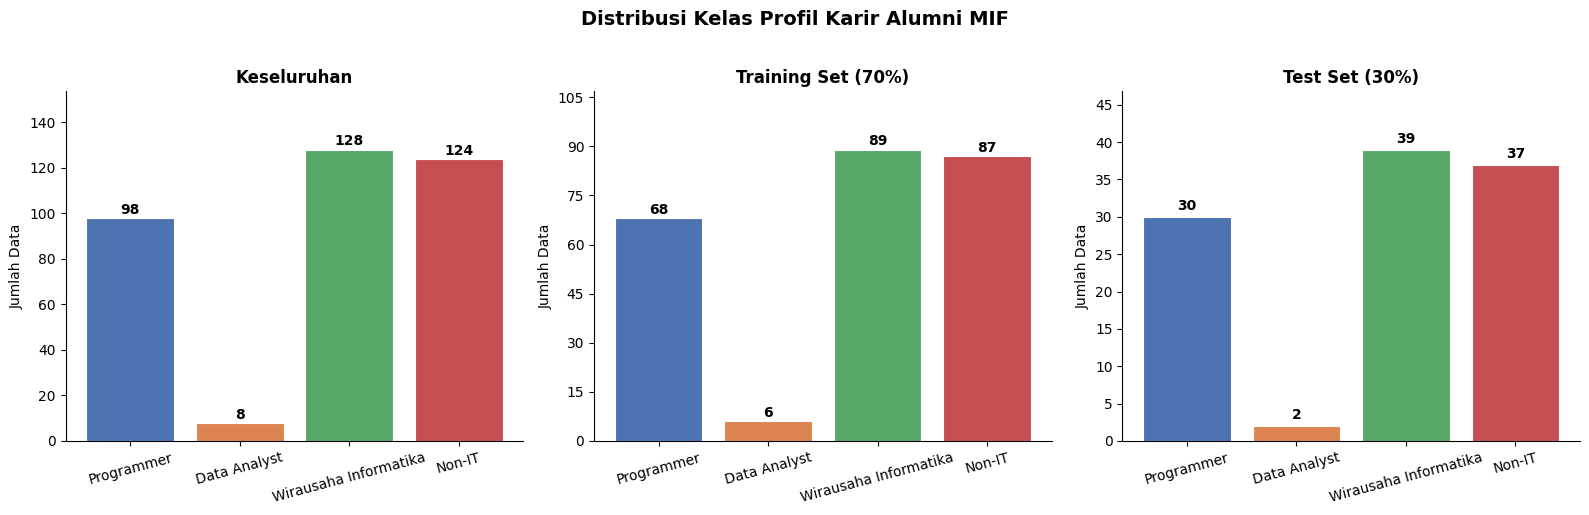

In [13]:
COLORS = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Distribusi Kelas Profil Karir Alumni MIF", fontsize=14, fontweight="bold", y=1.02)

for ax, (df_plot, title) in zip(axes, [
    (result, "Keseluruhan"),
    (train_df, "Training Set (70%)"),
    (test_df, "Test Set (30%)"),
]):
    counts = df_plot["label"].value_counts().reindex(TARGET_CLASSES, fill_value=0)
    bars = ax.bar(counts.index, counts.values, color=COLORS, edgecolor="white", linewidth=0.8)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel("Jumlah Data")
    ax.set_ylim(0, counts.max() * 1.2)
    ax.tick_params(axis="x", rotation=15)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                str(val), ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

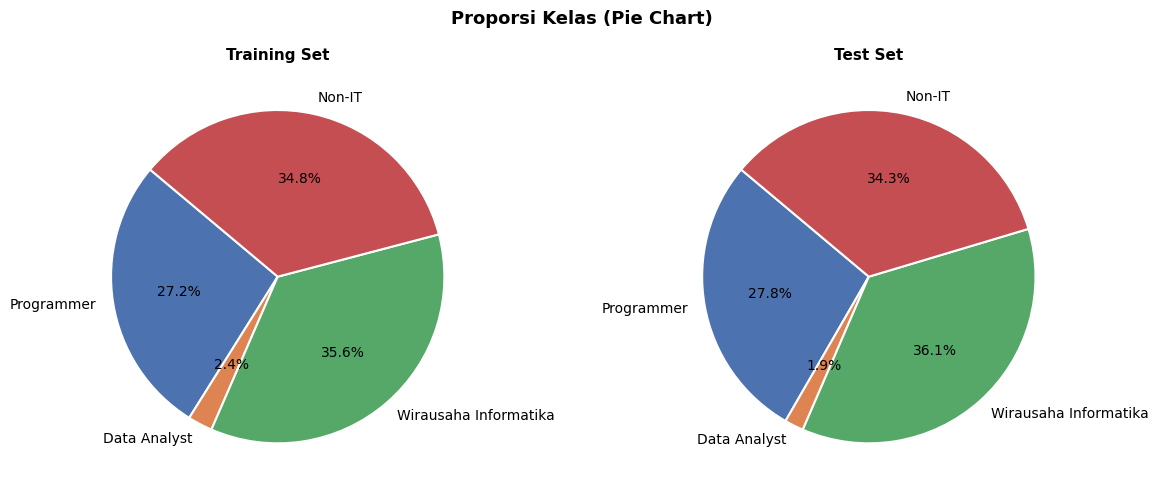


Corpus berhasil disiapkan dan disimpan.


In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Proporsi Kelas (Pie Chart)", fontsize=13, fontweight="bold")

for i, (df_plot, title) in enumerate([(train_df, "Training Set"), (test_df, "Test Set")]):
    counts = df_plot["label"].value_counts().reindex(TARGET_CLASSES, fill_value=0)
    ax[i].pie(
        counts.values,
        labels=counts.index,
        autopct="%1.1f%%",
        colors=COLORS,
        startangle=140,
        wedgeprops={"edgecolor": "white", "linewidth": 1.5}
    )
    ax[i].set_title(title, fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

print("\nCorpus berhasil disiapkan dan disimpan.")